# 1. Data Source: dbo.vw_FactSalesAnalysis
**Tools:** Python, Pandas, Matplotlib, SQL Server

In [3]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyodbc
plt.style.use("ggplot")
print("Libraries Imported Successfully")

Libraries Imported Successfully


# 2. SQL Server Connection

In [4]:
server = "DESKTOP-QU5OBIK"
database = "AdventureWorks2019"

connection_string = f"""
DRIVER={{SQL Server}};
SERVER={server};
DATABASE={database};
Trusted_Connection=yes;
"""
conn = pyodbc.connect(connection_string)
print("Connected Successfully")

Connected Successfully


# 3. Load Data

In [5]:
query = """
SELECT *
FROM dbo.vw_FactSalesAnalysis;
"""
df = pd.read_sql(query, conn)    #df ---> DataFrame
print("Data Loaded Successfully")

Data Loaded Successfully


In [6]:
df.head()

,SalesOrderID,SalesOrderDetailID,OrderDate,DueDate,ShipDate,OrderYear,OrderMonth,MonthName,OrderQuarter,OrderDay,...,UnitPriceDiscount,SalesAmount,CostAmount,Profit,ProfitMargin,TerritoryID,Territory,CountryRegionCode,TerritoryGroup,SalesPersonID
0,43659,1,2011-05-31,2011-06-12,2011-06-07,2011,5,May,2,31,...,0.0,2024.994,1898.0944,126.8996,6.2666,5,Southeast,US,North America,279.0
1,43659,2,2011-05-31,2011-06-12,2011-06-07,2011,5,May,2,31,...,0.0,6074.982,5694.2832,380.6988,6.2666,5,Southeast,US,North America,279.0
2,43659,3,2011-05-31,2011-06-12,2011-06-07,2011,5,May,2,31,...,0.0,2024.994,1898.0944,126.8996,6.2666,5,Southeast,US,North America,279.0
3,43659,4,2011-05-31,2011-06-12,2011-06-07,2011,5,May,2,31,...,0.0,2039.994,1912.1544,127.8396,6.2666,5,Southeast,US,North America,279.0
4,43659,5,2011-05-31,2011-06-12,2011-06-07,2011,5,May,2,31,...,0.0,2039.994,1912.1544,127.8396,6.2666,5,Southeast,US,North America,279.0


In [7]:
print("=" * 50)
print("Dataset Shape")
print("=" * 50)
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Dataset Shape
Rows    : 121317
Columns : 37


In [48]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 121317 entries, 0 to 121316
Data columns (total 37 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   SalesOrderID        121317 non-null  int64         
 1   SalesOrderDetailID  121317 non-null  int64         
 2   OrderDate           121317 non-null  datetime64[us]
 3   DueDate             121317 non-null  datetime64[us]
 4   ShipDate            121317 non-null  datetime64[us]
 5   OrderYear           121317 non-null  int64         
 6   OrderMonth          121317 non-null  int64         
 7   MonthName           121317 non-null  str           
 8   OrderQuarter        121317 non-null  int64         
 9   OrderDay            121317 non-null  int64         
 10  DayName             121317 non-null  str           
 11  Status              121317 non-null  int64         
 12  OnlineOrderFlag     121317 non-null  bool          
 13  CustomerID          121317 non-null  int

In [9]:
df.columns.tolist()

['SalesOrderID',
 'SalesOrderDetailID',
 'OrderDate',
 'DueDate',
 'ShipDate',
 'OrderYear',
 'OrderMonth',
 'MonthName',
 'OrderQuarter',
 'OrderDay',
 'DayName',
 'Status',
 'OnlineOrderFlag',
 'CustomerID',
 'CustomerName',
 'ProductID',
 'ProductName',
 'ProductNumber',
 'Color',
 'Class',
 'ProductLine',
 'StandardCost',
 'ListPrice',
 'Subcategory',
 'Category',
 'OrderQty',
 'UnitPrice',
 'UnitPriceDiscount',
 'SalesAmount',
 'CostAmount',
 'Profit',
 'ProfitMargin',
 'TerritoryID',
 'Territory',
 'CountryRegionCode',
 'TerritoryGroup',
 'SalesPersonID']

# 4. Data Validation

### Missing Values Review
The missing values found in some columns are expected based on the AdventureWorks business model and do not represent data quality issues.

In [ ]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage (%)": round(df.isnull().mean() * 100, 2)
})
missing = missing[missing["Missing Values"] > 0]
missing.sort_values(
    by="Missing Values",
    ascending=False
)
# ال SalesPerson  مش Miss Value  دي مبيعات اونلاين

,Missing Values,Percentage (%)
SalesPersonID,60398,49.79
Class,57443,47.35
Color,34145,28.15
ProductLine,2288,1.89


In [11]:
duplicates = df.duplicated().sum()
print(f"Duplicate Rows : {duplicates}")

Duplicate Rows : 0


In [12]:
df.dtypes

SalesOrderID                   int64
SalesOrderDetailID             int64
OrderDate             datetime64[us]
DueDate               datetime64[us]
ShipDate              datetime64[us]
OrderYear                      int64
OrderMonth                     int64
MonthName                        str
OrderQuarter                   int64
OrderDay                       int64
DayName                          str
Status                         int64
OnlineOrderFlag                 bool
CustomerID                     int64
CustomerName                     str
ProductID                      int64
ProductName                      str
ProductNumber                    str
Color                            str
Class                            str
ProductLine                      str
StandardCost                 float64
ListPrice                    float64
Subcategory                      str
Category                         str
OrderQty                       int64
UnitPrice                    float64
U

In [ ]:
df.describe().T   #Transpose

,count,mean,min,25%,50%,75%,max,std
SalesOrderID,121317.0,57827.363782,43659.0,49884.0,57029.0,65490.0,75123.0,9009.147902
SalesOrderDetailID,121317.0,60659.0,1.0,30330.0,60659.0,90988.0,121317.0,35021.345641
OrderDate,121317,2013-07-15 19:44:52.321768,2011-05-31 00:00:00,2013-02-28 00:00:00,2013-09-30 00:00:00,2014-01-31 00:00:00,2014-06-30 00:00:00,NaN
DueDate,121317,2013-07-27 19:45:12.262914,2011-06-12 00:00:00,2013-03-12 00:00:00,2013-10-12 00:00:00,2014-02-12 00:00:00,2014-07-12 00:00:00,NaN
ShipDate,121317,2013-07-22 19:45:12.262914,2011-06-07 00:00:00,2013-03-07 00:00:00,2013-10-07 00:00:00,2014-02-07 00:00:00,2014-07-07 00:00:00,NaN
OrderYear,121317.0,2013.034768,2011.0,2013.0,2013.0,2014.0,2014.0,0.820866
OrderMonth,121317.0,6.398567,1.0,3.0,6.0,9.0,12.0,3.351078
OrderQuarter,121317.0,2.459573,1.0,1.0,2.0,3.0,4.0,1.108311
OrderDay,121317.0,20.891928,1.0,11.0,27.0,30.0,31.0,10.797479
Status,121317.0,5.0,5.0,5.0,5.0,5.0,5.0,0.0


In [14]:
df.nunique().sort_values(ascending=False)

SalesOrderDetailID    121317
SalesOrderID           31465
CustomerID             19119
CustomerName           19018
Profit                  1576
SalesAmount             1488
CostAmount              1183
OrderDate               1124
DueDate                 1124
ShipDate                1124
UnitPrice                287
ProductName              266
ProductID                266
ProductNumber            266
ProfitMargin             153
StandardCost             100
ListPrice                 92
OrderQty                  41
Subcategory               35
OrderDay                  31
SalesPersonID             17
OrderMonth                12
MonthName                 12
TerritoryID               10
Territory                 10
UnitPriceDiscount          9
Color                      8
DayName                    7
CountryRegionCode          6
OrderQuarter               4
OrderYear                  4
Category                   4
ProductLine                4
Class                      3
TerritoryGroup

# 5. Exploratory Data Analysis (EDA)

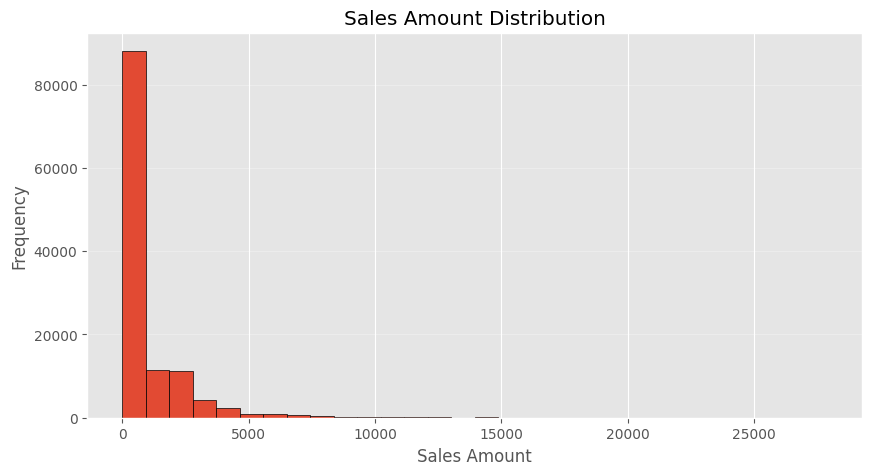

In [46]:
# الهدف هو معرفه توزيع المبيعات (هل هي في الاسعار صغيره ام الكبيره)
plt.figure(figsize=(10,5))
plt.hist(df["SalesAmount"], bins=30 , edgecolor="black")
plt.title("Sales Amount Distribution")
plt.xlabel("Sales Amount")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.3)
plt.show()

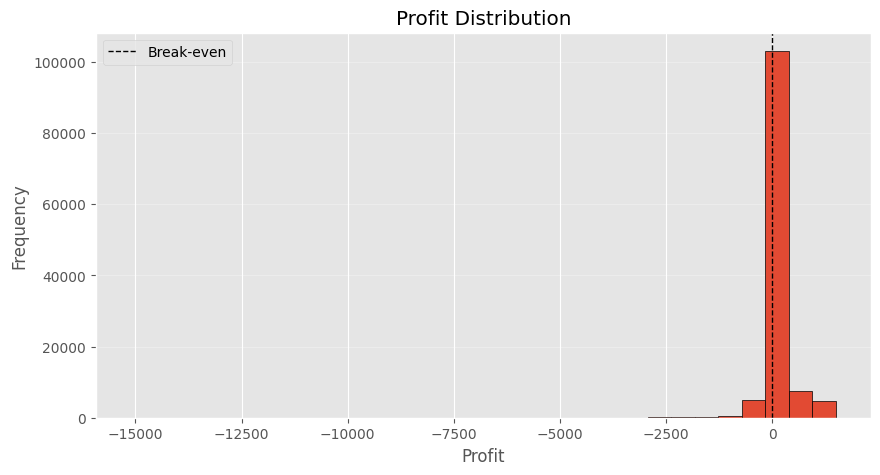

In [47]:
plt.figure(figsize=(10,5))
plt.hist(df["Profit"], bins=30 , edgecolor="black")
plt.axvline(
    x=0,
    color="black",
    linestyle="--",
    linewidth=1,
    label="Break-even"
)
plt.title("Profit Distribution")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.show()

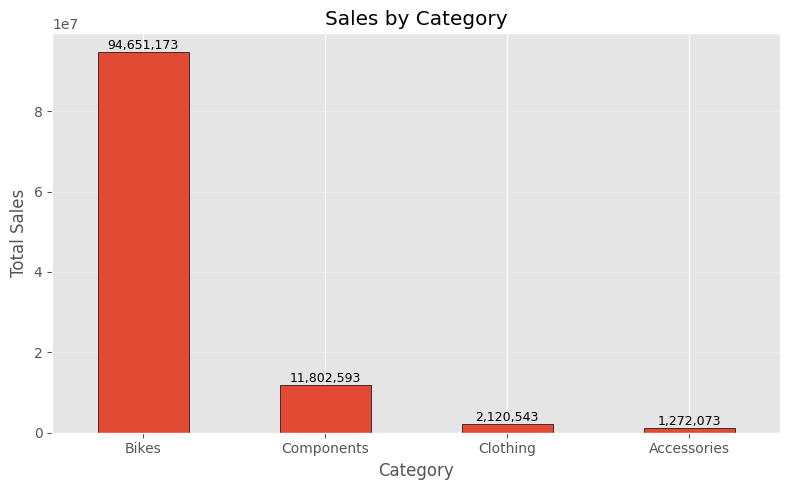

In [48]:
category_sales = (
    df.groupby("Category")["SalesAmount"]
      .sum()
      .sort_values(ascending=False)
)
plt.figure(figsize=(8,5))
category_sales.plot(
    kind="bar",
    edgecolor="black"
)
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
# Display values above bars
for i, value in enumerate(category_sales):
    plt.text(
        i,
        value,
        f"{value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9
    )
plt.tight_layout()
plt.show()

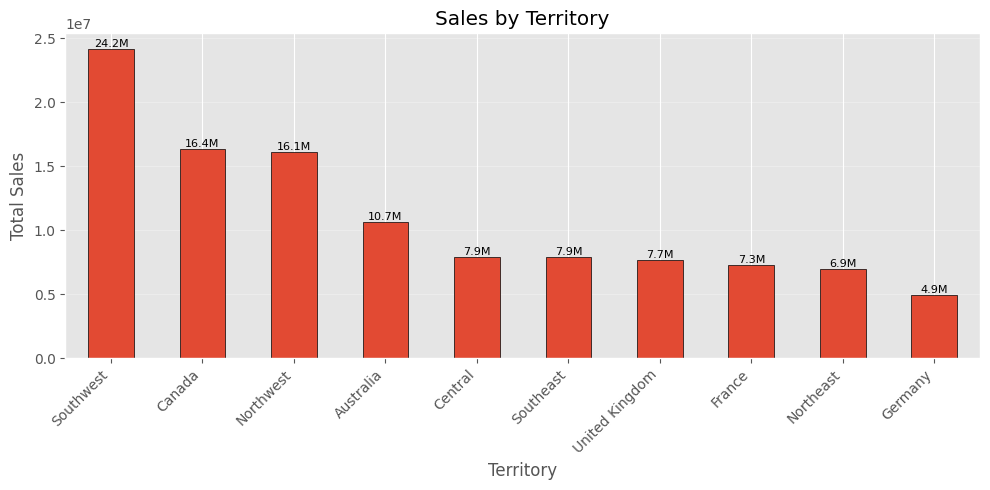

In [49]:
territory_sales = (
    df.groupby("Territory")["SalesAmount"]
      .sum()
      .sort_values(ascending=False)
)
plt.figure(figsize=(10,5))
territory_sales.plot(
    kind="bar",
    edgecolor="black"
)
plt.title("Sales by Territory")
plt.xlabel("Territory")
plt.ylabel("Total Sales")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
# Display values above bars
for i, value in enumerate(territory_sales):
    plt.text(
        i,
        value,
        f"{value/1_000_000:.1f}M",
        ha="center",
        va="bottom",
        fontsize=8
    )
plt.tight_layout()
plt.show()

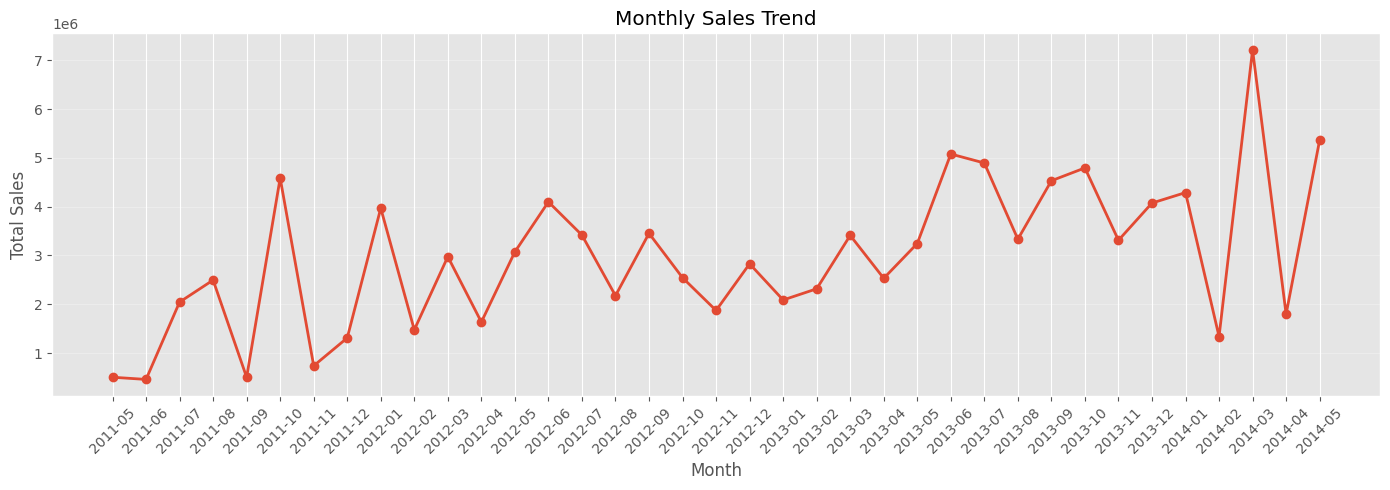

In [ ]:
monthly_sales = (
    df.groupby(["OrderYear", "OrderMonth"])["SalesAmount"]
      .sum()
      .reset_index()
)

monthly_sales["YearMonth"] = (
    monthly_sales["OrderYear"].astype(str)
    + "-"
    + monthly_sales["OrderMonth"].astype(str).str.zfill(2)
)

# Remove the last partial month (June 2014) // مش مكتمل ف شيلته
monthly_sales = monthly_sales.iloc[:-1]
plt.figure(figsize=(14,5))
plt.plot(
    monthly_sales["YearMonth"],
    monthly_sales["SalesAmount"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

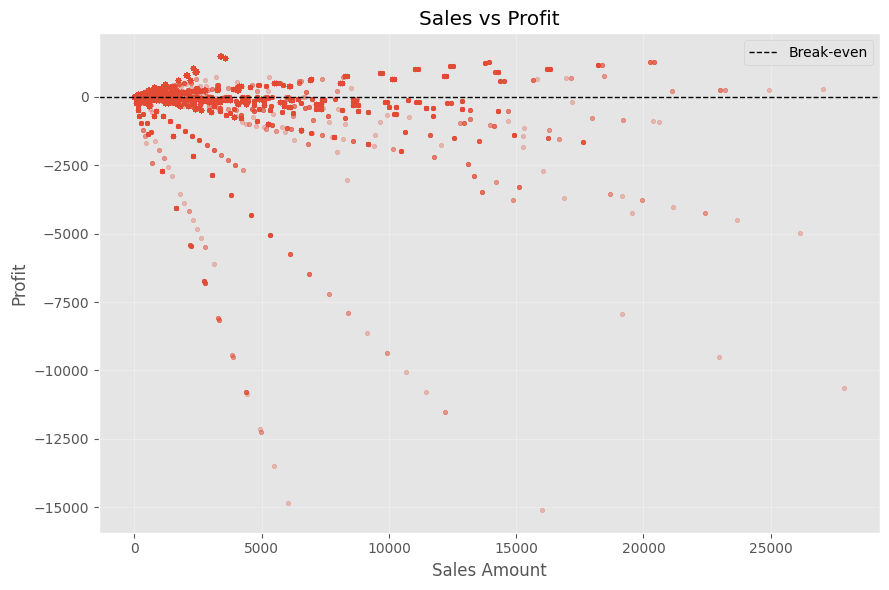

In [51]:
# Relationship between Sales and Profit
plt.figure(figsize=(9,6))
plt.scatter(
    df["SalesAmount"],
    df["Profit"],
    alpha=0.3,
    s=10
)

# Break-even Line
plt.axhline(
    y=0,
    color="black",
    linestyle="--",
    linewidth=1,
    label="Break-even"
)
plt.title("Sales vs Profit")
plt.xlabel("Sales Amount")
plt.ylabel("Profit")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 6. Correlation Analysis

In [27]:
corr_columns = [
    "SalesAmount",
    "Profit",
    "CostAmount",
    "OrderQty",
    "UnitPrice",
    "UnitPriceDiscount",
    "ProfitMargin"
]
corr = df[corr_columns].corr()
corr

,SalesAmount,Profit,CostAmount,OrderQty,UnitPrice,UnitPriceDiscount,ProfitMargin
SalesAmount,1.000000,0.089351,0.971650,0.304009,0.645878,0.021580,-0.304266
Profit,0.089351,1.000000,-0.148662,-0.193678,0.541759,-0.385830,0.333650
CostAmount,0.971650,-0.148662,1.000000,0.347812,0.512666,0.113012,-0.381293
OrderQty,0.304009,-0.193678,0.347812,1.000000,-0.076950,0.168855,-0.328770
UnitPrice,0.645878,0.541759,0.512666,-0.076950,1.000000,-0.012653,-0.164897
UnitPriceDiscount,0.021580,-0.385830,0.113012,0.168855,-0.012653,1.000000,-0.549025
ProfitMargin,-0.304266,0.333650,-0.381293,-0.328770,-0.164897,-0.549025,1.000000


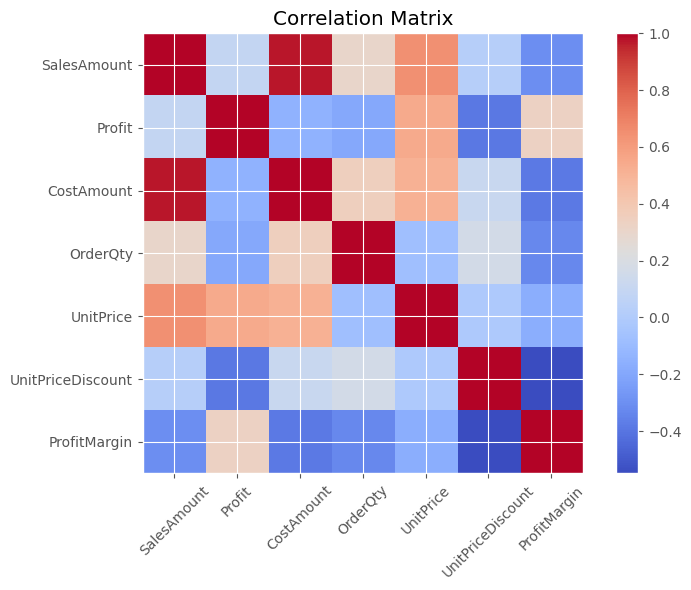

In [31]:
plt.figure(figsize=(8,6))
plt.imshow(corr, cmap="coolwarm")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

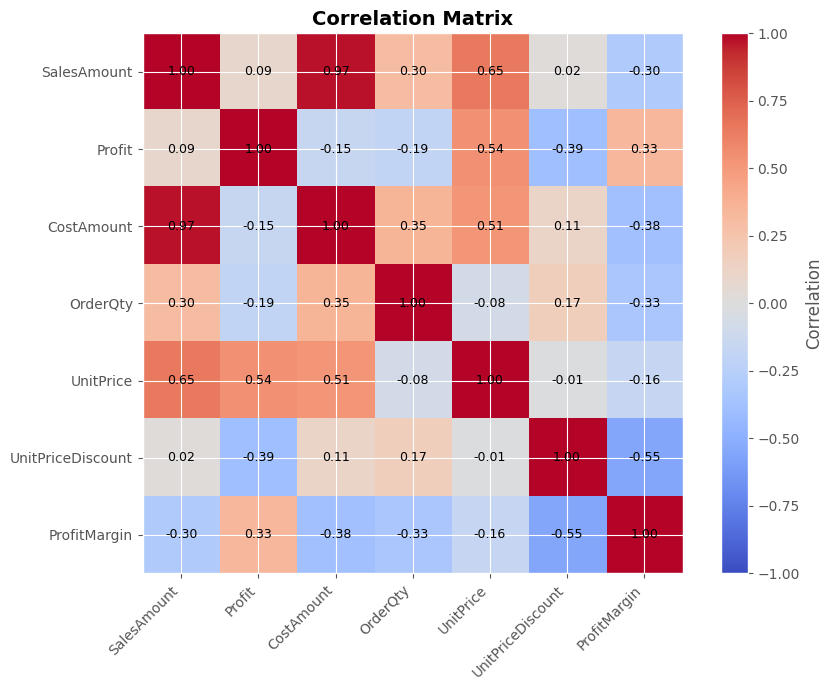

In [ ]:
# Correlation Heatmap (Matplotlib)
plt.figure(figsize=(9, 7))
im = plt.imshow(
    corr,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.colorbar(im, label="Correlation")
plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=45,
    ha="right"
)
plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

# Write Correlation Values Inside Cells
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(
            j,
            i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            color="black",
            fontsize=9
        )

plt.title("Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# 7. Outlier Detection

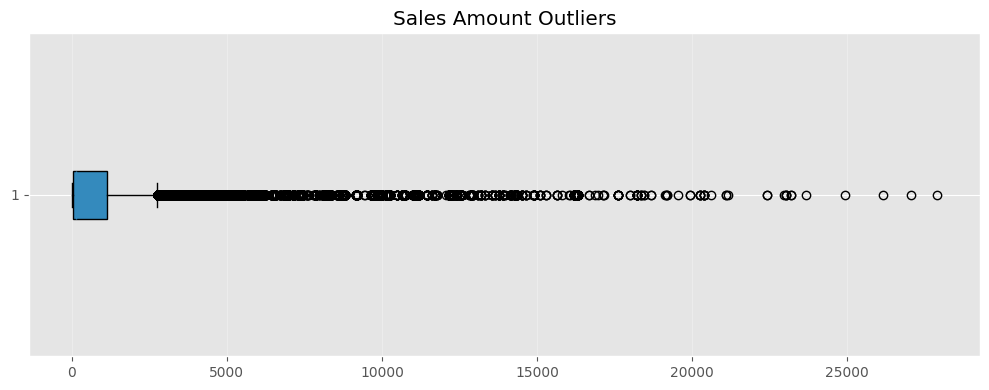

In [52]:
plt.figure(figsize=(10,4))
plt.boxplot(df["SalesAmount"], vert=False ,
    patch_artist=True)
plt.title("Sales Amount Outliers")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [33]:
Q1 = df["SalesAmount"].quantile(0.25)
Q3 = df["SalesAmount"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
sales_outliers = df[
    (df["SalesAmount"] < lower) |
    (df["SalesAmount"] > upper)
]
print(f"Sales Outliers : {len(sales_outliers)}")

Sales Outliers : 10737


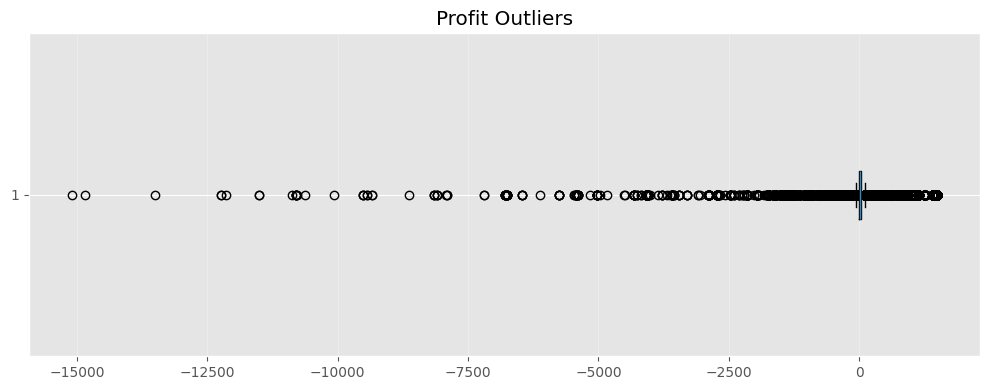

In [53]:
plt.figure(figsize=(10,4))
plt.boxplot(df["Profit"], vert=False)
plt.title("Profit Outliers")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [34]:
Q1 = df["Profit"].quantile(0.25)
Q3 = df["Profit"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
profit_outliers = df[
    (df["Profit"] < lower) |
    (df["Profit"] > upper)
]
print(f"Profit Outliers : {len(profit_outliers)}")

Profit Outliers : 36093


# 8. Key Findings

### Data Validation
- The dataset contains 121,317 records and 37 columns.
- No duplicate records were found.
- Missing values exist only in business-related optional fields (Color, Class, ProductLine, SalesPersonID).

### Exploratory Data Analysis
- Sales distribution is highly right-skewed.
- Bikes generate the highest sales among all product categories.
- Southwest is the best-performing sales territory.
- Some transactions generate negative profit despite positive sales.
- Outliers exist in SalesAmount and Profit, representing real business transactions.